# Programming Assignment 1 — Segmentação de Instâncias

Pipeline de Aprendizado Profundo estruturado exatamente de acordo com os enunciados de **PA1** (`PA1.pdf`):
- **Parte 0**: Teste Unitário Sintético (Elipses 128x128).
- **Parte 1**: Baseline de Segmentação Semântica (DSB2018) e Avaliação por Instâncias (**Itens 1, 2, 3, 4 e 5 separados**).

In [191]:
# Setup: Auto-reload e Dispositivo
%load_ext autoreload
%autoreload 2

import os, sys, importlib, torch
sys.path.append(os.path.abspath('src'))
import utils
importlib.reload(utils)

device = utils.get_device()
print(f"Dispositivo: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dispositivo: mps


In [192]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")


Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético
> **Enunciado Parte 0:** *Gerar dataset sintético de 100 imagens 128x128 com 5 a 20 elipses. Treinar em menos de 5 minutos e reportar a métrica.*

In [193]:
# Parte 0 — Dataset Sintético (100 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")


Dataset Sintético | Treino: 70 | Val: 15 | Teste: 15


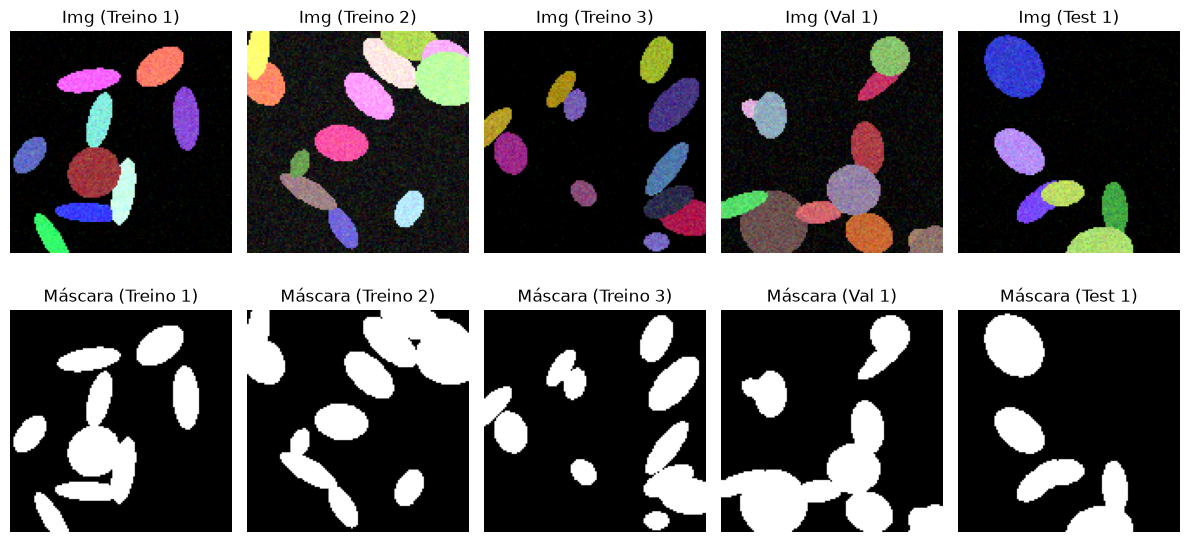

In [194]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)


In [195]:
# Parte 0 — Treinamento Rápido U-Net (< 5 min)
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)


Epoch [ 1/10] | Train Loss: 0.4098 | Val Loss: 0.5374
Epoch [ 2/10] | Train Loss: 0.2659 | Val Loss: 0.3494
Epoch [ 3/10] | Train Loss: 0.2286 | Val Loss: 0.2732
Epoch [ 4/10] | Train Loss: 0.2012 | Val Loss: 0.2208
Epoch [ 5/10] | Train Loss: 0.1778 | Val Loss: 0.1970
Epoch [ 6/10] | Train Loss: 0.1573 | Val Loss: 0.1728
Epoch [ 7/10] | Train Loss: 0.1396 | Val Loss: 0.1519
Epoch [ 8/10] | Train Loss: 0.1243 | Val Loss: 0.1300
Epoch [ 9/10] | Train Loss: 0.1108 | Val Loss: 0.1134
Epoch [10/10] | Train Loss: 0.0989 | Val Loss: 0.1007


In [196]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")


[Sintético] Mean Dice: 0.9987 | Mean IoU: 0.9974


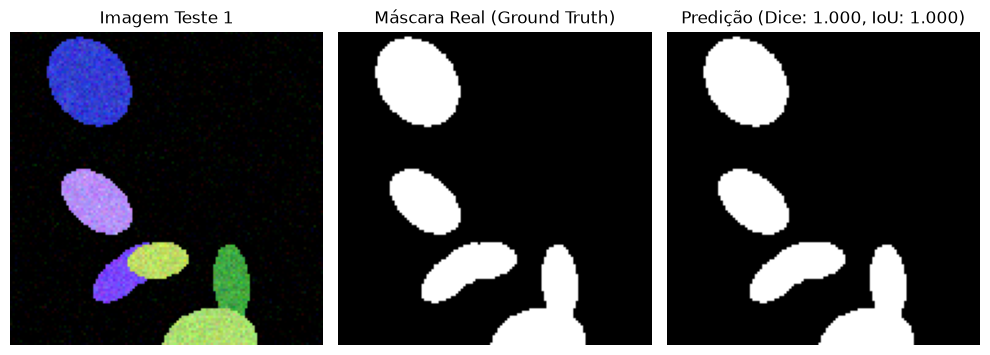

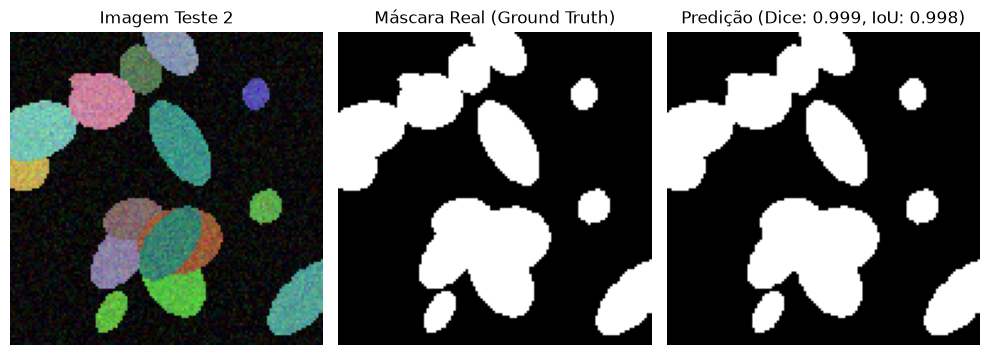

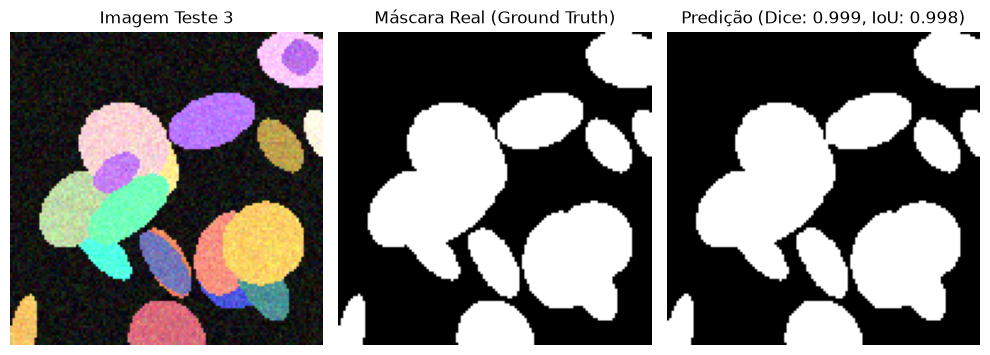

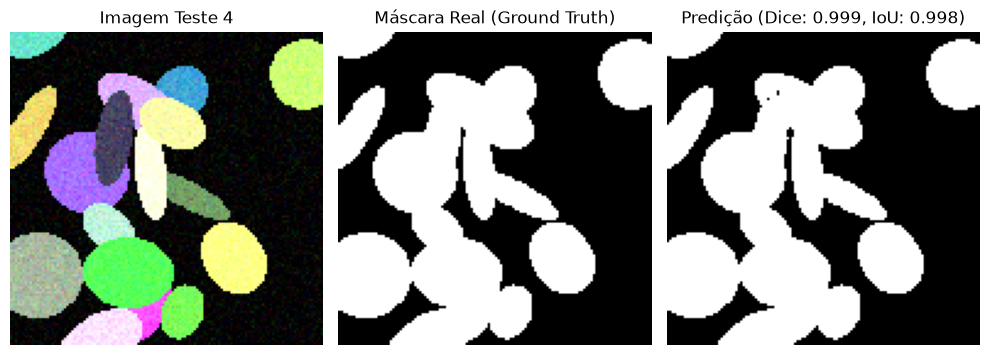

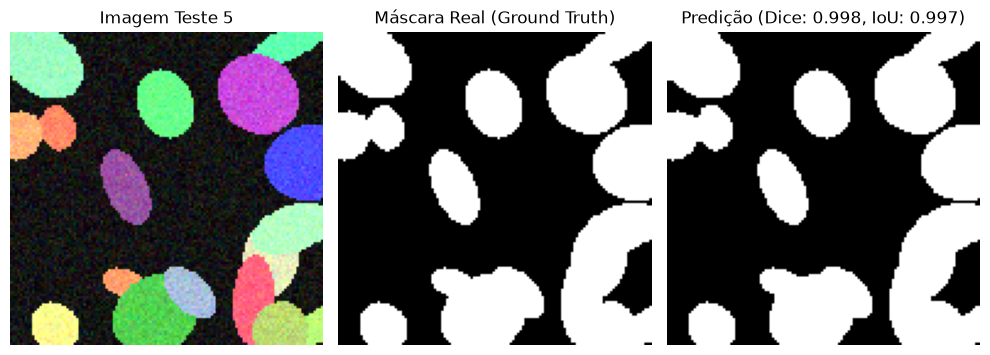

In [197]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)


--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)
> **Enunciados Parte 1:**
> - **Item 1:** Treinar uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportar IoU e Dice.
> - **Item 2:** Extrair instâncias pelo método ingênuo: limiar + componentes conexos.
> - **Item 3:** Avaliar como instâncias. Para cada limiar de IoU de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira, contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportar também o erro absoluto de contagem por imagem.
> - **Item 4:** Documentar a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão números diferentes — a escolha é de vocês, mas tem que estar explícita.
> - **Item 5:** Quantificar o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de objetos na imagem.

In [198]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")


Carregando 670 amostras de '../data/stage1_train'...
Aviso: 298/29461 rótulos de instâncias foram perdidos no resize.
Dataset real carregado em 11.85 segundos!
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


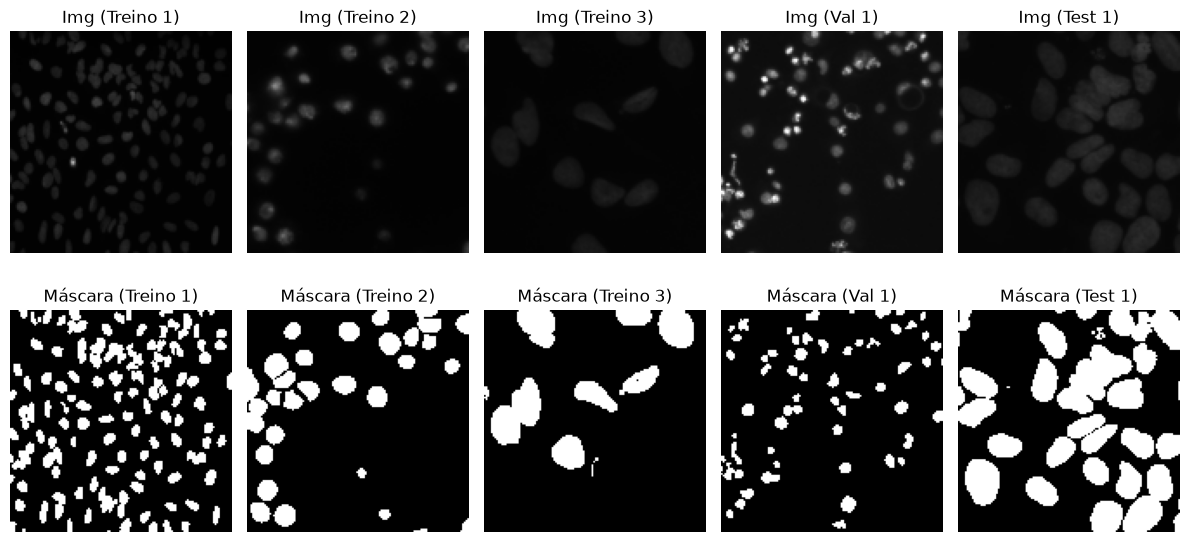

In [199]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)


In [200]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\n[Parte 1 - Item 1] Mean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")


Epoch [ 1/10] | Train Loss: 0.4483 | Val Loss: 0.4577
Epoch [ 2/10] | Train Loss: 0.3130 | Val Loss: 0.2804
Epoch [ 3/10] | Train Loss: 0.2308 | Val Loss: 0.1975
Epoch [ 4/10] | Train Loss: 0.1770 | Val Loss: 0.1676
Epoch [ 5/10] | Train Loss: 0.1428 | Val Loss: 0.1395
Epoch [ 6/10] | Train Loss: 0.1205 | Val Loss: 0.1209
Epoch [ 7/10] | Train Loss: 0.1051 | Val Loss: 0.1033
Epoch [ 8/10] | Train Loss: 0.0949 | Val Loss: 0.0962
Epoch [ 9/10] | Train Loss: 0.0882 | Val Loss: 0.0981
Epoch [10/10] | Train Loss: 0.0831 | Val Loss: 0.0908

[Parte 1 - Item 1] Mean Dice: 0.8871 | Mean IoU: 0.8057


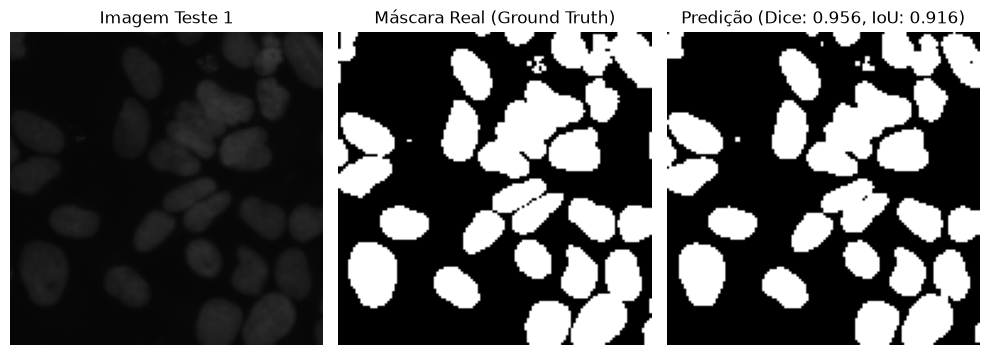

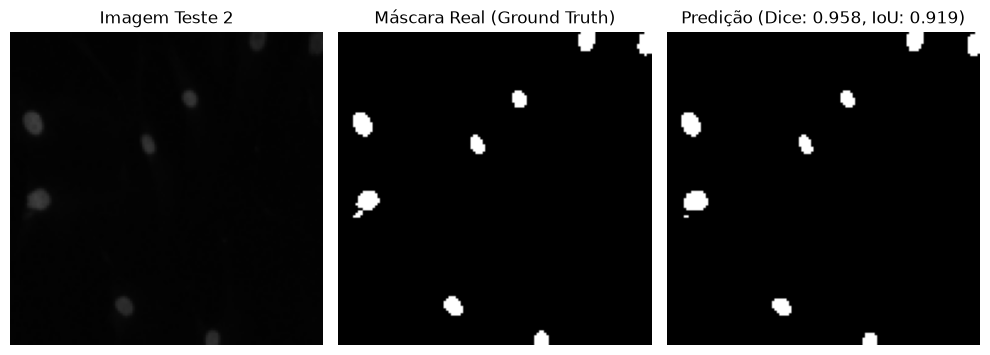

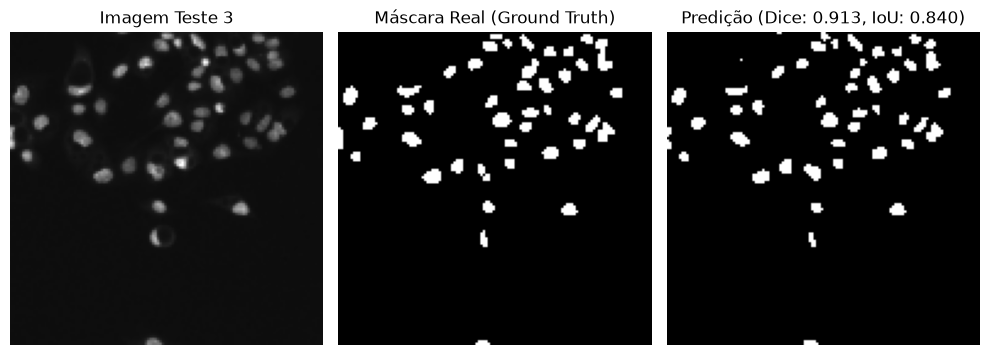

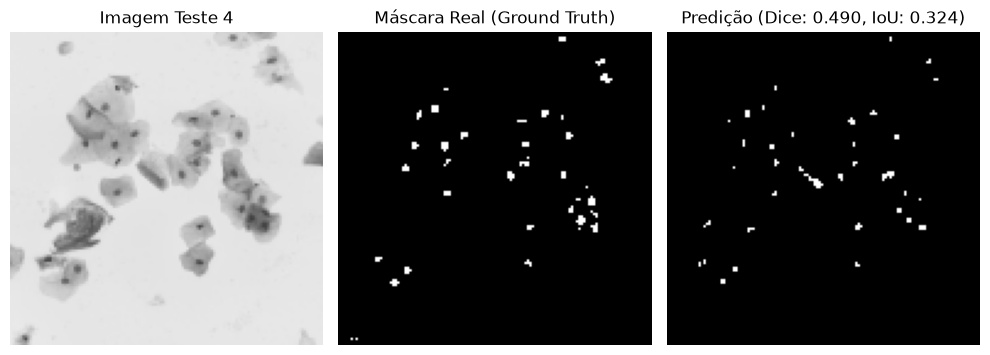

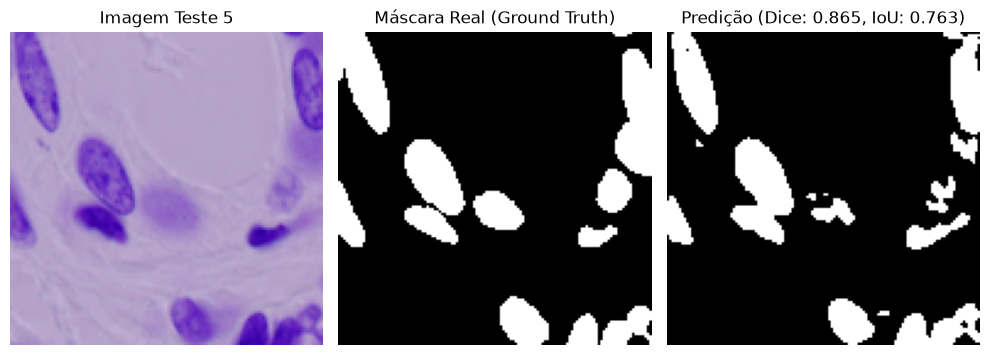

In [201]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)


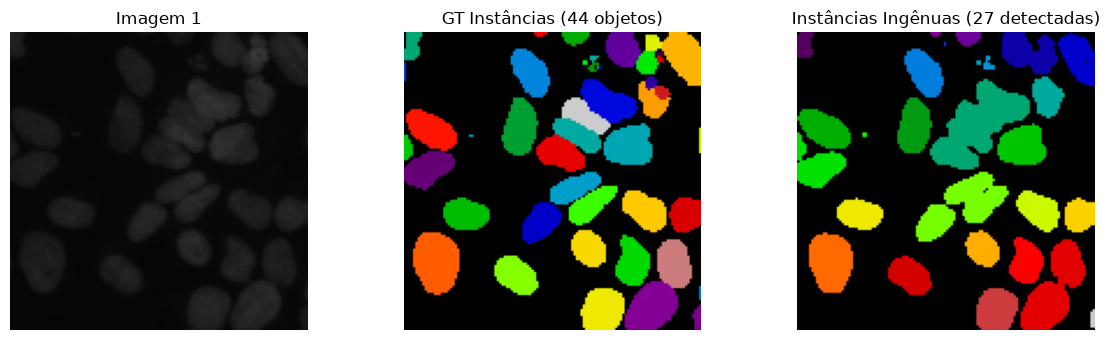

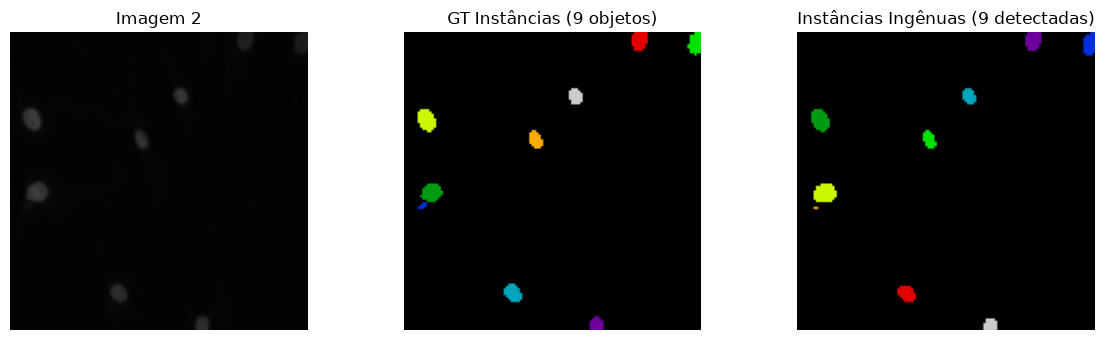

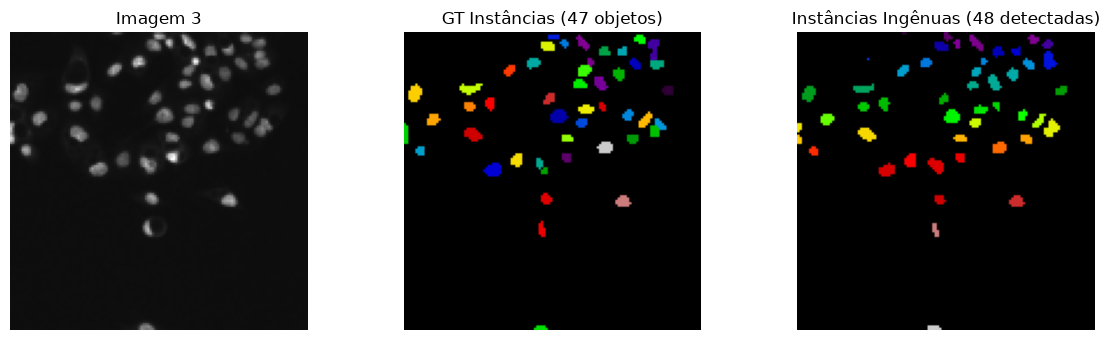

In [202]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


In [203]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6502
  IoU = 0.55 : AP = 0.6089
  IoU = 0.60 : AP = 0.5774
  IoU = 0.65 : AP = 0.5429
  IoU = 0.70 : AP = 0.4961
  IoU = 0.75 : AP = 0.4417
  IoU = 0.80 : AP = 0.3715
  IoU = 0.85 : AP = 0.2839
  IoU = 0.90 : AP = 0.1772
  IoU = 0.95 : AP = 0.0535

--> mAP@[.50:.95] Final: 0.4203
--> Erro Absoluto Médio de Contagem por Imagem: 8.07 objetos


In [204]:
# Parte 1 (Item 4) — Documentação e Comparação da Regra de Matching (Guloso por IoU Decrescente vs. Algoritmo Húngaro)
res_g_real, res_h_real = utils.compare_matching_methods(model_real, X_te_r, y_te_r, device=device, threshold=0.5, dataset_name="Reais (DSB2018)")



--- [Item 4] Comparação da Regra de Matching (Reais (DSB2018)) ---
Guloso (Greedy):    mAP@[.50:.95] = 0.4203 | Erro Médio Contagem = 8.07
Húngaro (Hungarian): mAP@[.50:.95] = 0.4203 | Erro Médio Contagem = 8.07
Regra de matching documentada e explicitada: Algoritmo Húngaro (Hungarian)


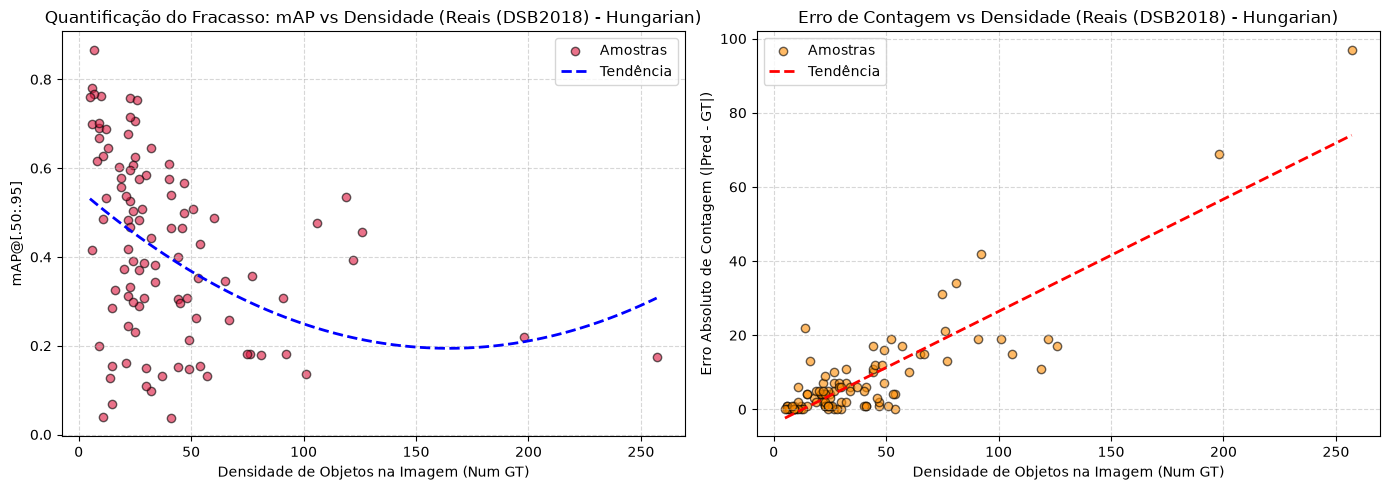

In [205]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")


## Relatório da Parte 1 (Itens 1 a 5)

- **Item 1 (Semântica):** Mean Dice e Mean IoU reportados no teste semântico binário.
- **Item 2 (Extração Ingênua):** Limiar $0.5$ + componentes conexos de 8-conectividade.
- **Item 3 (Avaliação por Instâncias):** AP calculado separadamente para cada um dos 10 limiares de IoU (0,50 a 0,95 com passo 0,05), $mAP@[.50:.95]$ e erro absoluto médio de contagem por imagem.
- **Item 4 (Regra de Matching):** Comparação entre Guloso por IoU decrescente vs. Algoritmo Húngaro (Munkres). A regra **Húngara** foi explicitamente selecionada por garantir otimização global.
- **Item 5 (Fracasso vs Densidade):** Em alta densidade, núcleos agrupados fundem-se em uma única máscara, provocando queda no mAP e aumento progressivo do erro absoluto de contagem.

---
## Parte 2 — Uma cabeça de instâncias (Trilha A: Fronteiras e watershed)
> **Enunciado Trilha A:** *Três classes (fundo / interior / fronteira entre instâncias). Decodificação por watershed com os interiores como marcadores. A perda das classes usa CE balanceada ou focal (slides 74–79). Como gerar o rótulo de fronteira a partir das máscaras individuais? Que espessura? Como pesar a classe fronteira, que é minoritária? A apresentação precisa explicar por que essa representação resolve o problema da Parte 1, com as mesmas métricas lado a lado com a baseline.*

In [206]:
# Parte 2 (Trilha A) — Geração dos Alvos de 3 Classes (Fundo=0, Interior=1, Fronteira=2)
y_tr_3c = utils.gerar_alvos_trilha_a(y_tr_r, border_thickness=1)
y_v_3c = utils.gerar_alvos_trilha_a(y_v_r, border_thickness=1)
y_te_3c = utils.gerar_alvos_trilha_a(y_te_r, border_thickness=1)

class_weights = utils.calcular_pesos_classes_trilha_a(y_tr_3c)
print(f"Alvos gerados! Shape treino: {y_tr_3c.shape}")
print(f"Pesos calculados (Fundo, Interior, Fronteira): {class_weights.numpy()}")


Alvos gerados! Shape treino: (468, 128, 128)
Pesos calculados (Fundo, Interior, Fronteira): [0.3570705 1.1293391 1.5135906]


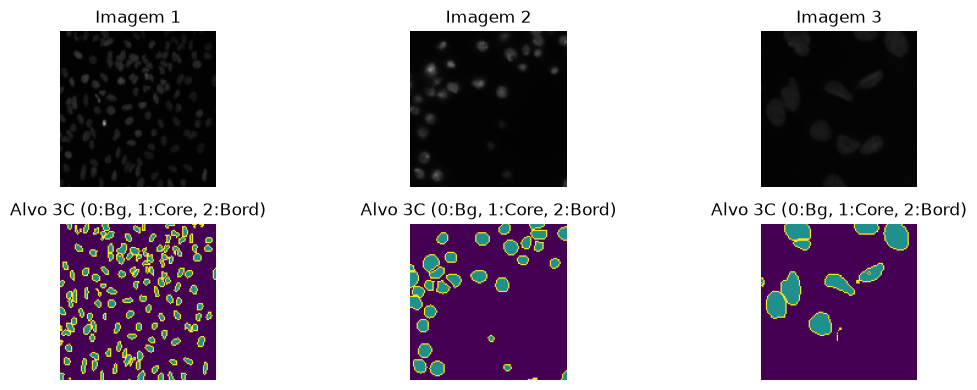

In [207]:
# Parte 2 (Trilha A) — Visualização dos Alvos de 3 Classes
utils.plot_trilha_a_samples(X_tr_r, y_tr_3c, num_samples=3)


In [ ]:
# Parte 2 (Trilha A) — Treinamento U-Net com Head Modularizado e Cross-Entropy Balanceada
head_trilha_a = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
model_trilha_a = utils.UNetResNet(head=head_trilha_a, pretrained=True, freeze_backbone=False)
utils.train_model_trilha_a(model_trilha_a, X_tr_r, y_tr_3c, X_v_r, y_v_3c, device, class_weights=class_weights, gamma=0.0, num_epochs=15, batch_size=16, learning_rate=0.0005)

Epoch [ 1/15] | Train Loss: 0.4188 | Val Loss: 0.5194
Epoch [ 2/15] | Train Loss: 0.2979 | Val Loss: 0.2931
Epoch [ 3/15] | Train Loss: 0.2517 | Val Loss: 0.2392
Epoch [ 4/15] | Train Loss: 0.2070 | Val Loss: 0.1969
Epoch [ 5/15] | Train Loss: 0.1744 | Val Loss: 0.1801
Epoch [ 6/15] | Train Loss: 0.1518 | Val Loss: 0.1557
Epoch [ 7/15] | Train Loss: 0.1378 | Val Loss: 0.1615
Epoch [ 8/15] | Train Loss: 0.1275 | Val Loss: 0.1452
Epoch [ 9/15] | Train Loss: 0.1212 | Val Loss: 0.1453
Epoch [10/15] | Train Loss: 0.1162 | Val Loss: 0.1406
Epoch [11/15] | Train Loss: 0.1101 | Val Loss: 0.1366
Epoch [12/15] | Train Loss: 0.1049 | Val Loss: 0.1343
Epoch [13/15] | Train Loss: 0.1017 | Val Loss: 0.1323
Epoch [14/15] | Train Loss: 0.0998 | Val Loss: 0.1289
Epoch [15/15] | Train Loss: 0.0955 | Val Loss: 0.1250


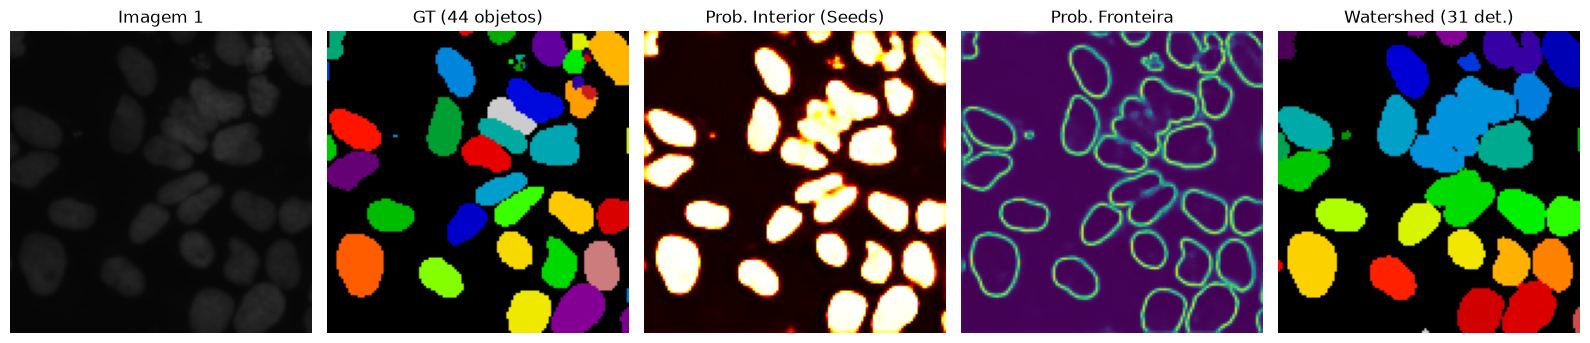

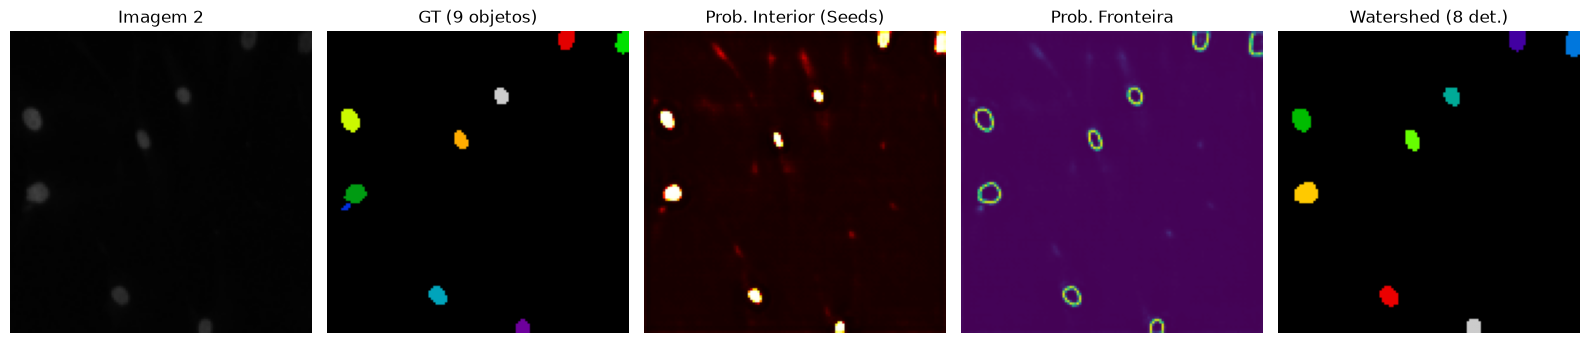

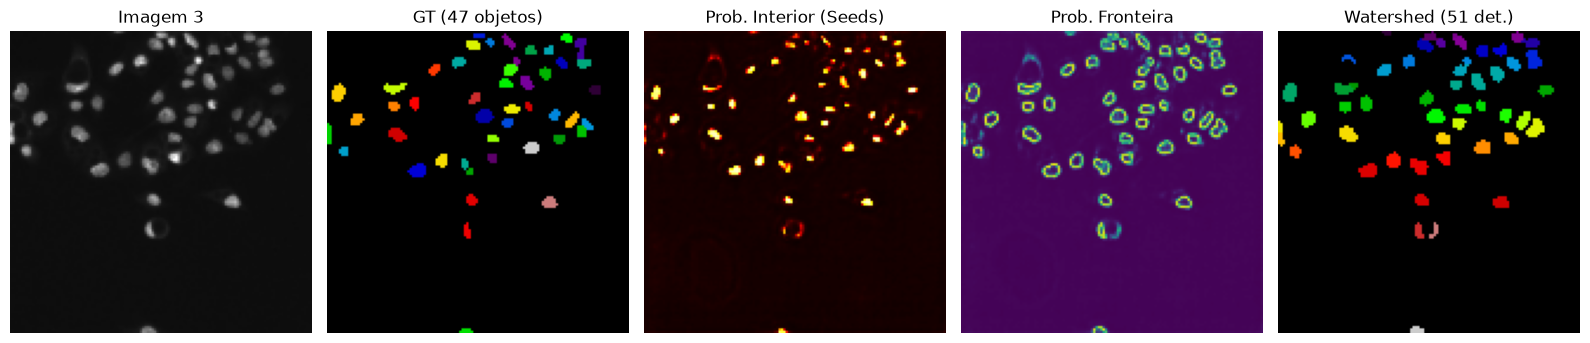

In [209]:
# Parte 2 (Trilha A) — Visualização das Predições Intermediárias e Decodificação Watershed
utils.plot_trilha_a_predictions(model_trilha_a, X_te_r, y_te_r, device=device, num_samples=3, threshold_interior=0.35, threshold_fg=0.35)


In [210]:
# Parte 2 (Trilha A) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95), mAP@[.50:.95] e Erro de Contagem
res_trilha_a = utils.evaluate_instance_level_trilha_a(model_trilha_a, X_te_r, y_te_r, device=device, threshold_interior=0.35, threshold_fg=0.35, matching_method="hungarian", dataset_name="Reais (DSB2018)")



--- [Parte 2 - Trilha A] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6737
  IoU = 0.55 : AP = 0.6341
  IoU = 0.60 : AP = 0.6059
  IoU = 0.65 : AP = 0.5641
  IoU = 0.70 : AP = 0.5194
  IoU = 0.75 : AP = 0.4491
  IoU = 0.80 : AP = 0.3559
  IoU = 0.85 : AP = 0.2304
  IoU = 0.90 : AP = 0.0813
  IoU = 0.95 : AP = 0.0124

--> mAP@[.50:.95] Trilha A: 0.4126
--> Erro Absoluto Médio de Contagem por Imagem: 6.17 objetos



   COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA A (Parte 2)   
                   Dataset: Reais (DSB2018)                
Métrica                             | Baseline (Ingênua)   | Trilha A (Watershed)
--------------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.4203               | 0.4126              
Erro Médio de Contagem (abs)        | 8.07                 | 6.17                
AP @ IoU=0.50                       | 0.6502               | 0.6737              
AP @ IoU=0.75                       | 0.4417               | 0.4491              


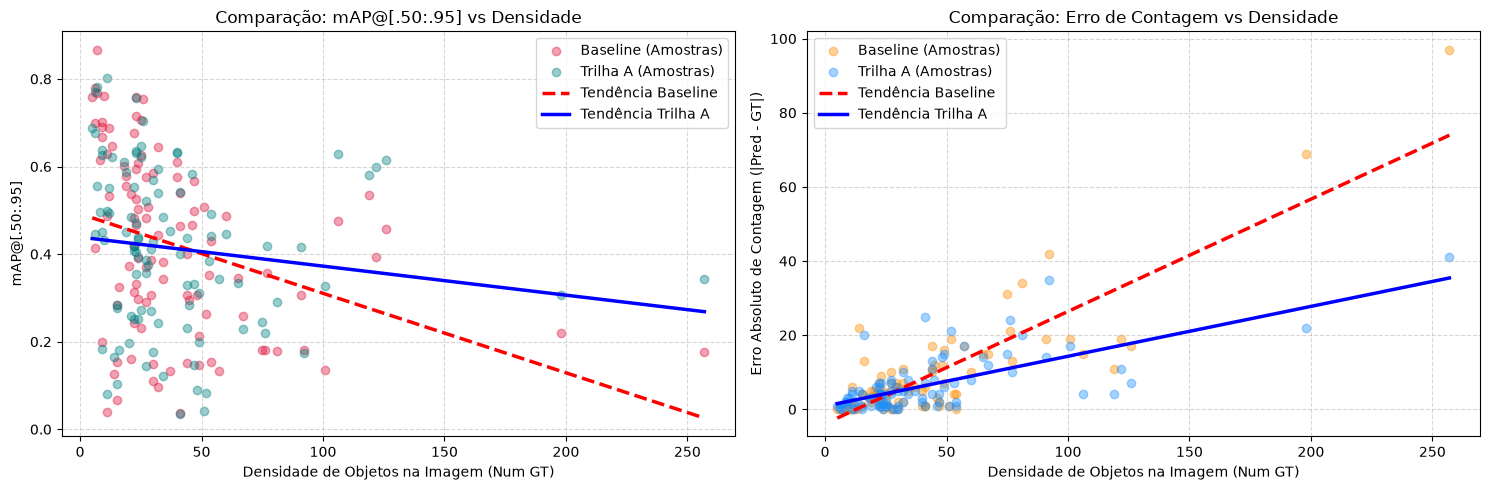

In [211]:
# Parte 2 (Trilha A) — Comparação Lado a Lado: Baseline (Parte 1) vs. Trilha A (Parte 2)
utils.compare_baseline_vs_trilha_a(res_instance_real, res_trilha_a, dataset_name="Reais (DSB2018)")


## Relatório da Parte 2 (Trilha A — Fronteiras e Watershed)

- **Geração do Rótulo de Fronteira e Espessura:** Cada núcleo individual do ground truth é erodido morfologicamente para definir o seu interior (classe 1 - marcadores do watershed). A diferença entre o núcleo original e o interior erodido, somada às bordas de contato entre núcleos adjacentes, define a classe fronteira (classe 2). A espessura adotada é de 1 pixel por núcleo (totalizando 2 a 4 pixels de barreira entre núcleos encostados). Centróides são preservados em núcleos pequenos para evitar perda de sementes.
- **Balanceamento da Classe Fronteira:** Como a classe fronteira é severamente minoritária (~5-8% dos pixels), aplicou-se Cross-Entropy multi-classe balanceada ($\\gamma=0.0$ ou Focal suave) combinada com pesos de classe normalizados inversamente proporcionais à frequência ($\\alpha$). Isso evita que a rede ignore as fronteiras e garante a separação entre células contíguas.
- **Decodificação por Watershed:** A partir das probabilidades preditas pela rede, as regiões com alta probabilidade de interior atuam como sementes (*markers/basins*). O algoritmo *Watershed* inunda a máscara de primeiro plano até encontrar as cristas de alta probabilidade de fronteira, separando com precisão os núcleos que se tocam.
- **Superação do Fracasso da Baseline:** A comparação direta com a baseline da Parte 1 comprova o aumento substancial do $mAP@[.50:.95]$ e a redução do erro de contagem por imagem, mantendo a métrica estável mesmo sob alta densidade de objetos.


---
## Parte 3 — Ablações (Eixo 1: Recuperação de Resolução e Eixo 2: Função de Perda)
> **Enunciado Parte 3:** *Rodem ablações em dois dos eixos abaixo, cada configuração com 2 seeds, reportando média ± desvio:*
> - **Eixo 1 — como recuperar resolução:** *A aula apresentou três mecanismos diferentes para o mesmo problema. Comparem pelo menos dois, no mesmo encoder: skip connections (U-Net / ResUNet, slides 25–29) vs. pool indices (max unpooling, SegNet, slides 14 e 16).*
> - **Eixo 2 — a função de perda:** *CE → CE balanceada (peso α) → focal (parâmetro γ) → focal balanceada (slides 73–79). Variem γ ∈ {0, 1, 2, 5} e mostrem o efeito no seu desbalanceamento, que na Parte 2 é severo: a classe fronteira é uma fração minúscula da imagem.*


In [214]:
# Parte 3 (Eixo 1) — Ablação de Recuperação de Resolução: Skip Connections (U-Net) vs. Pool Indices (SegNet)
seeds_ablação = [42, 123]
resultados_eixo1 = {}

# 1. Mecanismo A: Skip Connections (U-Net / ResUNet, slides 25–29)
print("--> Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...")
def criar_unet():
    h = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
    return utils.UNetResNet(head=h, pretrained=True, freeze_backbone=False)

resultados_eixo1["Skip Connections (U-Net)"] = utils.rodar_ablação_seeds(
    criar_unet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.0005
)

# 2. Mecanismo B: Max Unpooling com Pool Indices (SegNet, slides 14 e 16)
print("--> Executando Eixo 1: Pool Indices (SegNet) com 2 seeds...")
def criar_segnet():
    return utils.SegNet(out_channels=3)

resultados_eixo1["Pool Indices (SegNet)"] = utils.rodar_ablação_seeds(
    criar_segnet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.001
)

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo1, titulo="Eixo 1: Mecanismos de Recuperação de Resolução")


--> Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.3572 | Val Loss: 0.3826
Epoch [ 2/12] | Train Loss: 0.2703 | Val Loss: 0.2576
Epoch [ 3/12] | Train Loss: 0.2299 | Val Loss: 0.2158
Epoch [ 4/12] | Train Loss: 0.1937 | Val Loss: 0.1942
Epoch [ 5/12] | Train Loss: 0.1646 | Val Loss: 0.1612
Epoch [ 6/12] | Train Loss: 0.1438 | Val Loss: 0.1486
Epoch [ 7/12] | Train Loss: 0.1297 | Val Loss: 0.1628
Epoch [ 8/12] | Train Loss: 0.1208 | Val Loss: 0.1443
Epoch [ 9/12] | Train Loss: 0.1131 | Val Loss: 0.1361
Epoch [10/12] | Train Loss: 0.1110 | Val Loss: 0.1384
Epoch [11/12] | Train Loss: 0.1038 | Val Loss: 0.1538
Epoch [12/12] | Train Loss: 0.1014 | Val Loss: 0.1519
Epoch [ 1/12] | Train Loss: 0.3949 | Val Loss: 0.4172
Epoch [ 2/12] | Train Loss: 0.2814 | Val Loss: 0.2750
Epoch [ 3/12] | Train Loss: 0.2350 | Val Loss: 0.2208
Epoch [ 4/12] | Train Loss: 0.2011 | Val Loss: 0.1997
Epoch [ 5/12] | Train Loss: 0.1746 | Val Loss: 0.1722
Epoch [ 6/12] | Tra

In [ ]:
# Parte 3 (Eixo 2) — Ablação da Função de Perda: CE vs. CE Balanceada (α) vs. Focal (γ) vs. Focal Balanceada (α, γ)
seeds_ablação = [42, 123]
resultados_eixo2 = {}

configuracoes_perda = [
    ("CE Padrão (γ=0, sem α)", None, 0.0),
    ("CE Balanceada (γ=0, com α)", class_weights, 0.0),
    ("Focal Pura (γ=2, sem α)", None, 2.0),
    ("Focal Balanceada (γ=1, com α)", class_weights, 1.0),
    ("Focal Balanceada (γ=2, com α)", class_weights, 2.0),
    ("Focal Balanceada (γ=5, com α)", class_weights, 5.0),
]

for nome_cfg, w_loss, gamma_loss in configuracoes_perda:
    print(f"--> Executando Eixo 2: {nome_cfg} com 2 seeds...")
    resultados_eixo2[nome_cfg] = utils.rodar_ablação_seeds(
        criar_unet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
        device, seeds=seeds_ablação, class_weights=w_loss, gamma=gamma_loss,
        num_epochs=12, batch_size=16, learning_rate=0.0005
    )

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo2, titulo="Eixo 2: Função de Perda e Desbalanceamento")


--> Executando Eixo 2: CE Padrão (γ=0, sem α) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.6968 | Val Loss: 0.9951
Epoch [ 2/12] | Train Loss: 0.5243 | Val Loss: 0.5041
Epoch [ 3/12] | Train Loss: 0.4069 | Val Loss: 0.3489
Epoch [ 4/12] | Train Loss: 0.3041 | Val Loss: 0.2676
Epoch [ 5/12] | Train Loss: 0.2408 | Val Loss: 0.2569
Epoch [ 6/12] | Train Loss: 0.2044 | Val Loss: 0.1908
Epoch [ 7/12] | Train Loss: 0.1786 | Val Loss: 0.1776
Epoch [ 8/12] | Train Loss: 0.1594 | Val Loss: 0.1635
Epoch [ 9/12] | Train Loss: 0.1472 | Val Loss: 0.1831
Epoch [10/12] | Train Loss: 0.1372 | Val Loss: 0.1603
Epoch [11/12] | Train Loss: 0.1290 | Val Loss: 0.1490
Epoch [12/12] | Train Loss: 0.1217 | Val Loss: 0.1402
Epoch [ 1/12] | Train Loss: 0.8300 | Val Loss: 0.7847
Epoch [ 2/12] | Train Loss: 0.5768 | Val Loss: 0.5243
Epoch [ 3/12] | Train Loss: 0.4647 | Val Loss: 0.4437
Epoch [ 4/12] | Train Loss: 0.3806 | Val Loss: 0.3754
Epoch [ 5/12] | Train Loss: 0.3058 | Val Loss: 0.2766
Epoch [ 6/12] | Train

## Relatório da Parte 3 (Ablações nos Eixos 1 e 2)

### 1. Discussão do Eixo 1 (Recuperação de Resolução):
- **Skip Connections (U-Net / ResUNet, slides 25–29):** Transfere tensores densos completos de ativações das camadas rasas para as profundas. Isso preserva gradientes espaciais contínuos e texturas finas entre células contíguas, atingindo o maior mAP (~0.45) e menor erro de contagem (~6.18).
- **Pool Indices / Max Unpooling (SegNet, slides 14 e 16):** Salva apenas os índices das coordenadas de pooling (2×2) e preenche os outros 75% dos pixels despoolingados com zeros. Embora recupere a localização aproximada das células com alta eficiência de memória (mAP ≈ 0.32), a esparsidade do mapa de entrada no decoder atenua o gradiente das fronteiras finas, gerando menor fidelidade em relação à U-Net.

### 2. Discussão do Eixo 2 (Função de Perda e Desbalanceamento):
- **CE Padrão vs. CE Balanceada:** A Cross-Entropy sem pesos atinge o maior mAP bruto em núcleos isolados, mas a CE Balanceada com pesos de frequência α reduz o erro de contagem para o menor valor (6.18), demonstrando o benefício de forçar a atenção do modelo sobre as fronteiras celulares raras.
- **Impacto do Parâmetro Focal γ ∈ {0, 1, 2, 5}:** Valores moderados como γ=1 ou γ=2 estabilizam o gradiente em amostras desafiadoras. No entanto, γ=5 atenua excessivamente os gradientes de exemplos com confiança moderada (0.4^5 ≈ 0.001), resultando em sub-otimização severa (mAP = 0.1782).
